## Agent I

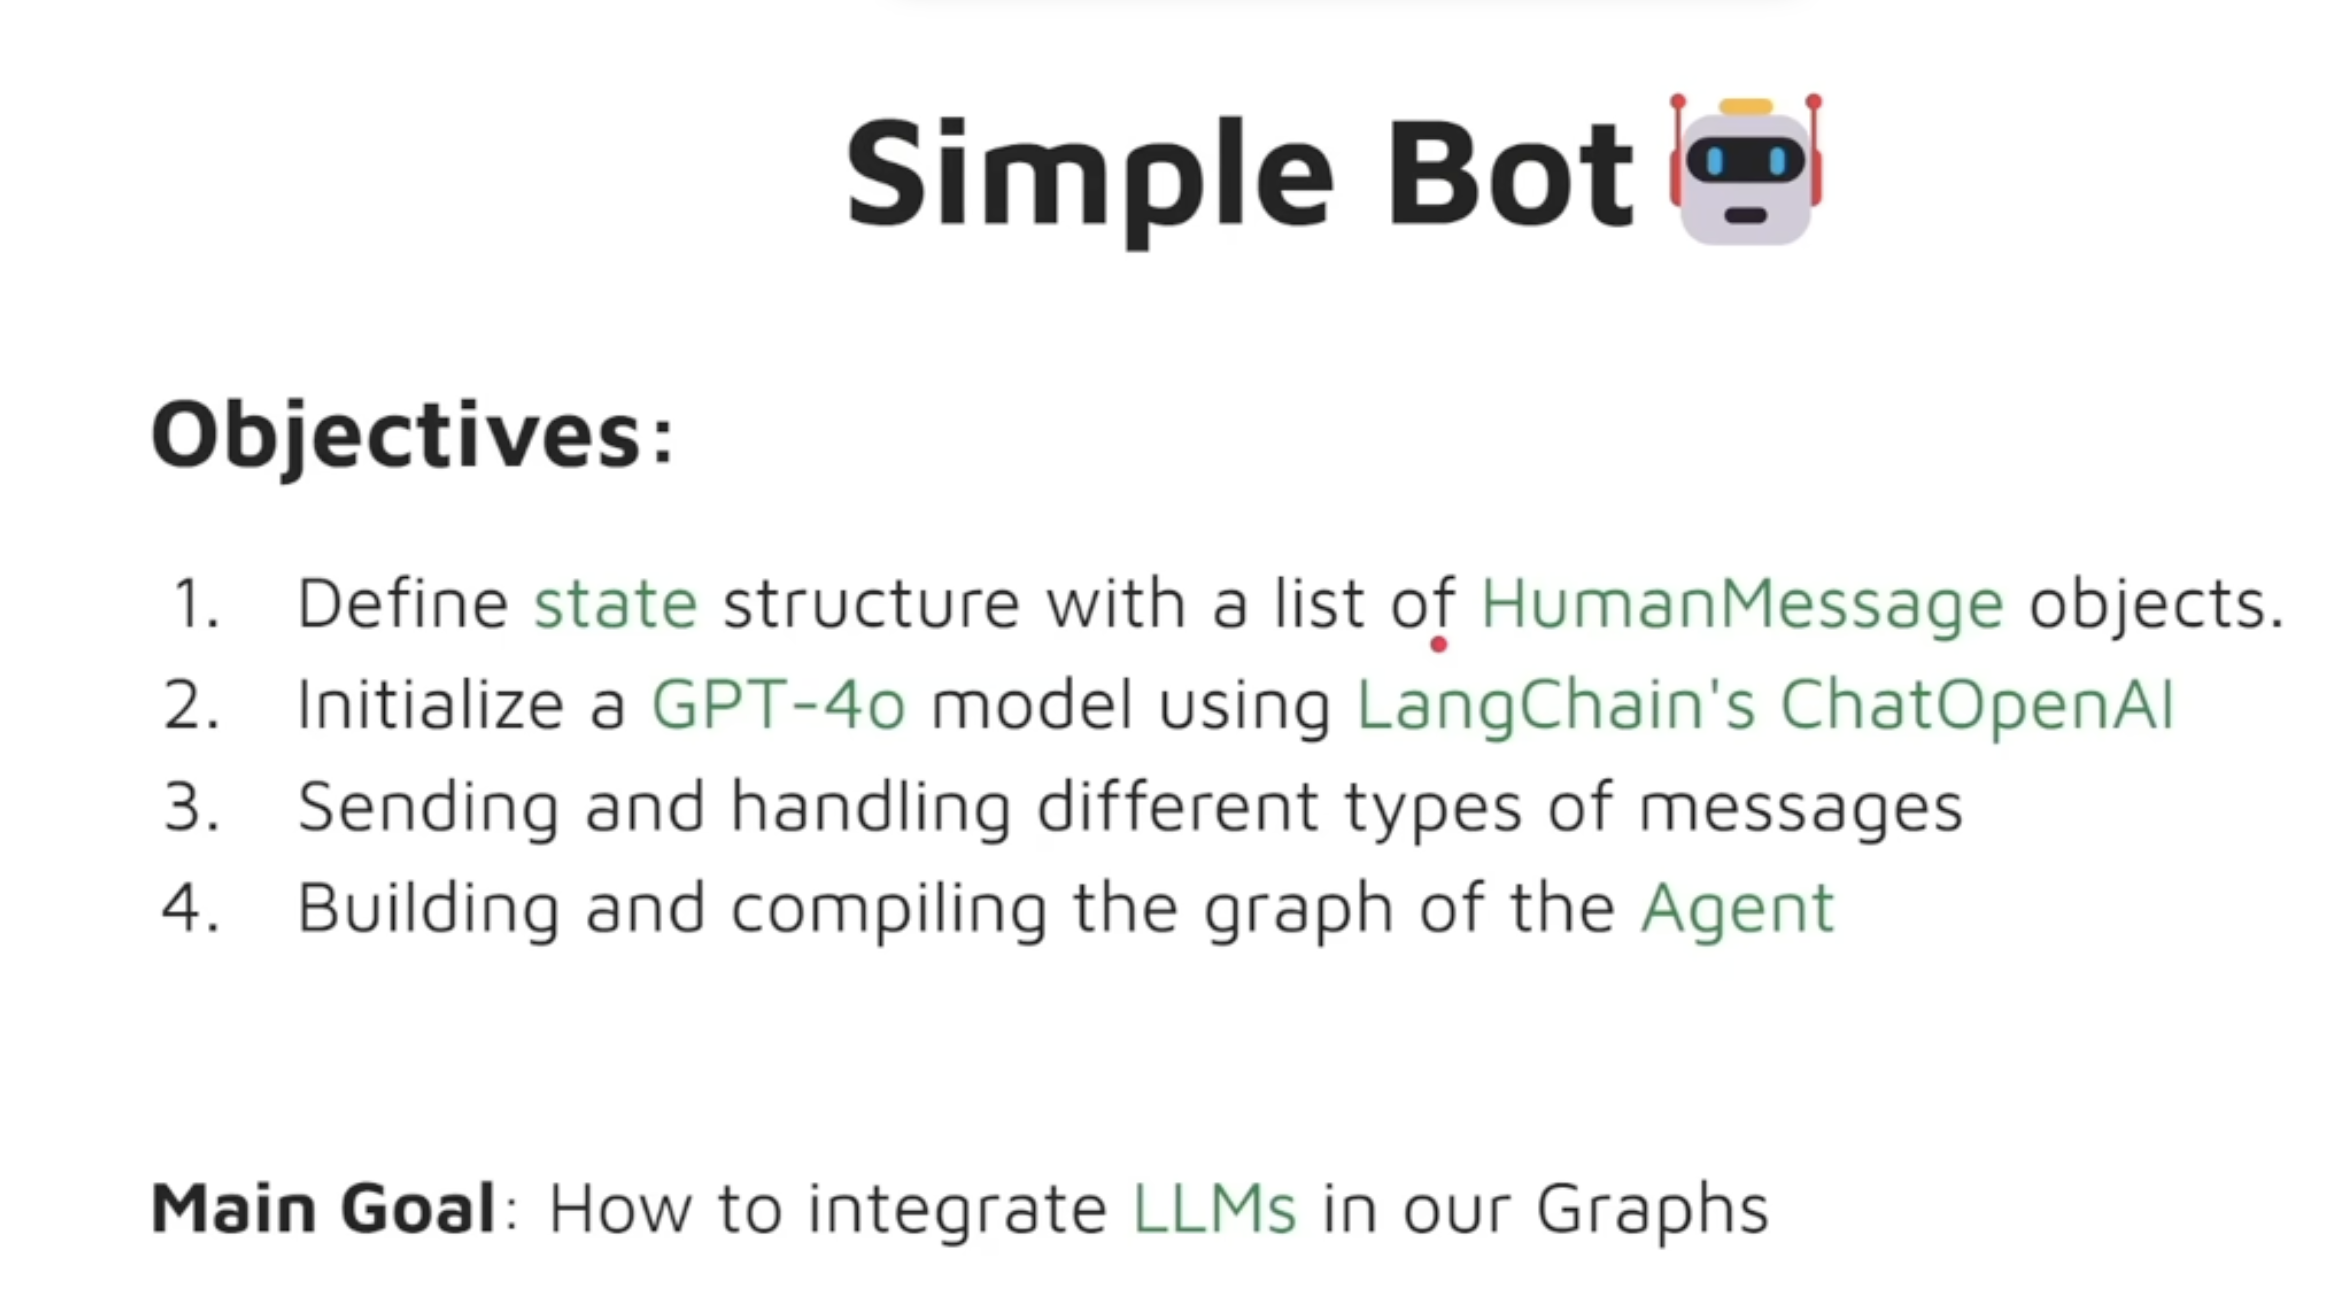

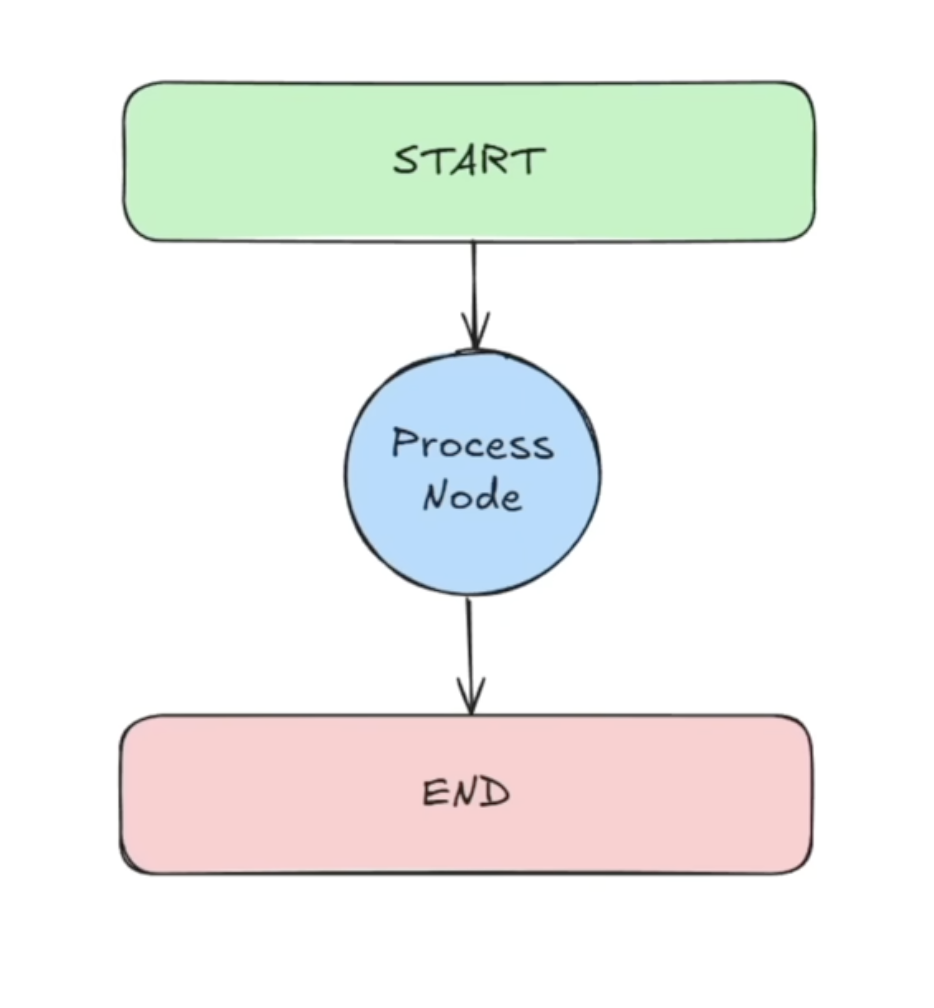

In [3]:
!pip install langchain_openai

In [4]:
!pip install -U langchain-google-genai

  Attempting uninstall: langchain-google-genai
    Found existing installation: langchain-google-genai 4.2.6
    Uninstalling langchain-google-genai-4.2.6:
      Successfully uninstalled langchain-google-genai-4.2.6


In [5]:
from typing import Union,Optional,Any,List,Dict,TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv ## used to store secret stuff like API keys or configuration values
## Langgraph is designed to use the robust libraries of langchain

In [6]:
## we need api keys to communicate with the LLMs
## we need api keys to call external LLMs

In [7]:
load_dotenv() ## it is used to check whether .env() file is loaded or not

## load_dotenv() returns a Boolean value.

# True → It found a .env file and loaded at least one variable.
# False → It couldn't find a .env file, or nothing was loaded


# Python reads the .env file and makes those values available as environment variables.
# Then you can access them like this:


True

In [9]:
class AgentState(TypedDict):
    messages:List[HumanMessage] # when we invoke the graph we are inputting human messages so we tell LLM that this is Human Message( message from me aka human)


## to initalize the model

llm=ChatGoogleGenerativeAI(model='gemini-2.5-flash')



def process(state:AgentState)->AgentState:
    ## How to call the LLM ? 
    # To call the graph or make the graph run we use app.invoke()
    ## similarly to run llm we use invoke as well
    response=llm.invoke(state['messages'])
    print(f"\n AI:{response.content}")
    return state

graph=StateGraph(AgentState)
graph.add_node('process',process)
graph.add_edge(START,'process')
graph.add_edge('process',END)
agent=graph.compile()

In [10]:
user_input=input("Enter:")

agent.invoke({'messages':[HumanMessage(content=user_input)]})

## in this you are able to write one sentence only not list of sentences


 AI:Hello Priyanshu! It's nice to meet you.

How can I assist you today?


{'messages': [HumanMessage(content='I am Priyanshu', additional_kwargs={}, response_metadata={})]}

In [11]:
## to keep iterating

user_input=input("Enter:")

while user_input!='exit':
    agent.invoke({'messages':[HumanMessage(content=user_input)]})
    user_input=input("Enter: ")

## in this you are able to write one sentence only not list of sentences


 AI:Hello Priyanshu! It's nice to meet you.

 AI:As an AI, I don't have access to your personal identity or any information about you. I don't know your name, age, gender, location, or any personal details. Our interaction is purely text-based, and I only process the information you provide in our current conversation.

So, to me, you are the user interacting with me right now!

If you'd like to tell me something about yourself, or if you're asking in a more philosophical sense, please elaborate!


## Important: in this code , we have not created some sort of memory, that is why it is called a bot...this is not even an agent yet


## Agent II

We will be creating a chatbot with some sort of memory

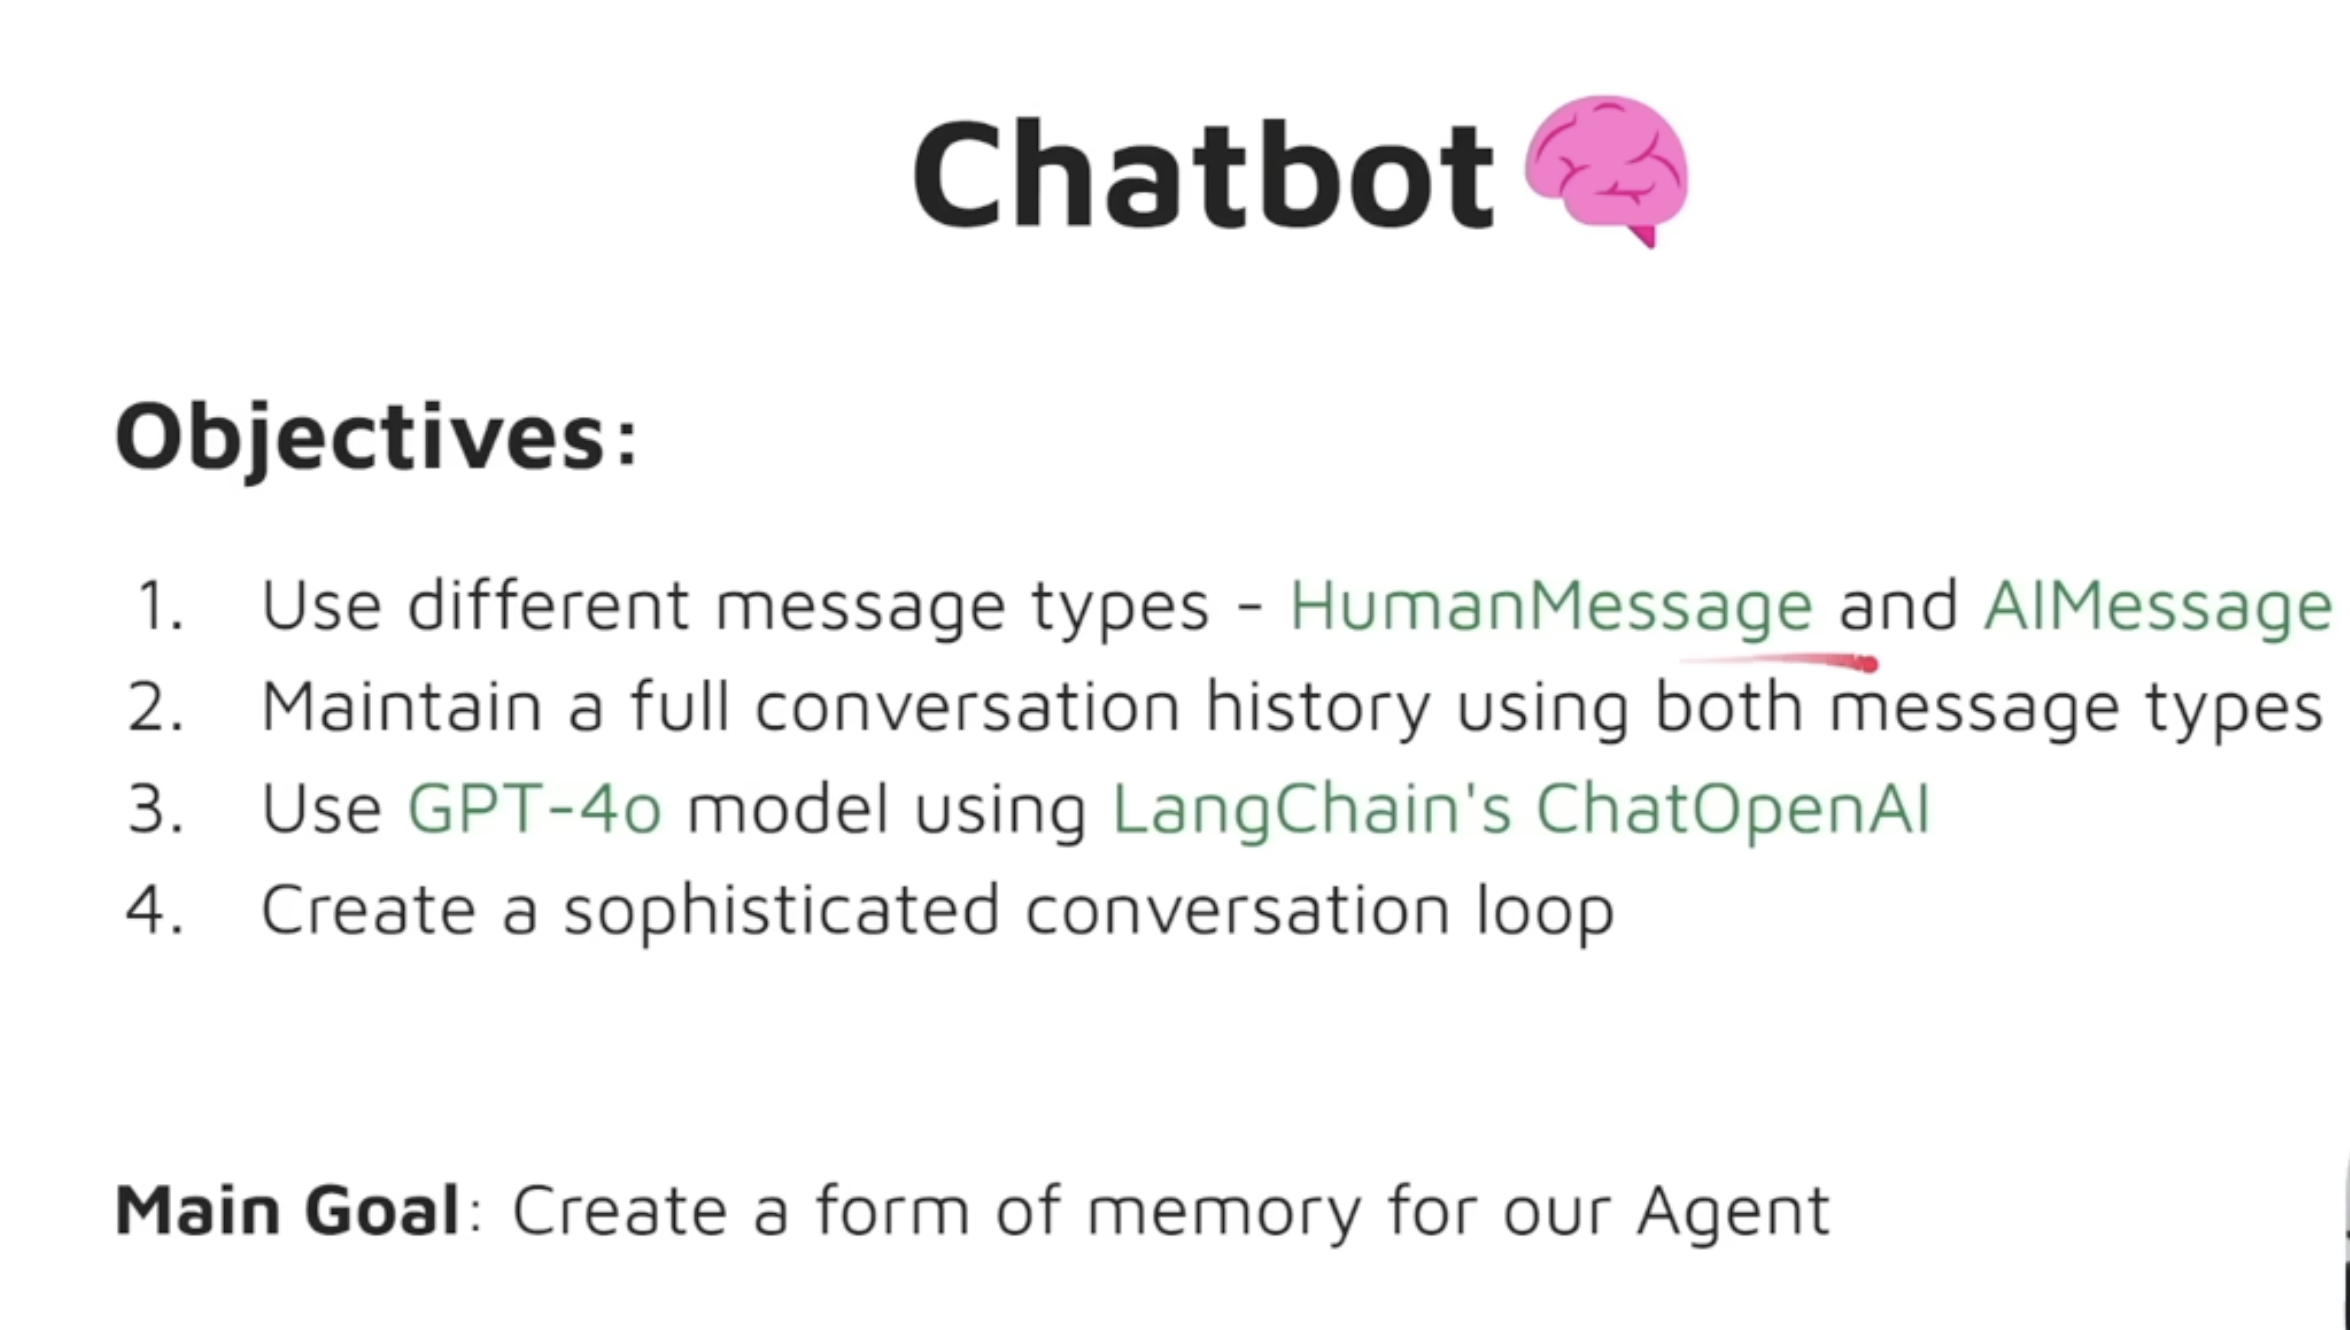

In [12]:
import os
from dotenv import load_dotenv
from typing import TypedDict,Dict,List,Union
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import START,END,StateGraph
from langchain_core.messages import HumanMessage,AIMessage

load_dotenv()

True

In [13]:
class AgentState(TypedDict):
    messages:List[Union[AIMessage,HumanMessage]]

# HumanMessage and AIMessage are inbuilt data types within Langgraph and Langchain

llm=ChatGoogleGenerativeAI(model='gemini-2.5-flash')


def process(state:AgentState)->AgentState:
    ''' this node will do solve the request of your input'''
    response=llm.invoke(state['messages'])
    state['messages'].append(AIMessage(content=response.content)) ## response.content only extracts the answer or the result after we call the LLM 
    print(f"\n AI:{response.content}")
    ## response =answer + amount of tokens you use + amount of tokens in response ..etc
    ## to get answer only we use response.content
    return state

In [14]:
graph=StateGraph(AgentState)
graph.add_node("process",process)
graph.add_edge(START,"process")
graph.add_edge("process",END)
agent=graph.compile()

conversation_history=[]

In [15]:
user_input=input("Enter:")
while user_input!='Exit':
    conversation_history.append(HumanMessage(content=user_input)) ## content is a parameter in HumanMessage
    result=agent.invoke({'messages':conversation_history}) ## not just current user prompt is not sent as well as entire conversation_history
    conversation_history=result['messages']
    user_input=input("Enter: ")


 AI:Hello Priyanshu! It's great to meet you.

I'm an AI assistant, ready to help. What can I do for you today?

 AI:That's a deep question, Priyanshu!

As an AI, I don't have personal information about you or access to your identity beyond what you choose to tell me in our conversation.

From my perspective, right now, you are **Priyanshu**, a unique individual who is currently interacting with me.

The true answer to "who am I?" is something only you can truly know, based on your experiences, thoughts, feelings, and the incredible journey of your life.

If you'd like to share more about yourself, or perhaps explore that question further, I'm here to listen and chat!


In [16]:
## it does know what I just said ago

Two big problems:


1-if I do exit and try to use agent again, everything is wiped out.. if i ask who am I ? it won't be able to answer

Answer is to store it in a database like RAG database

For now let's store it in a text file



2- State['message'] length is becoming longer and longer if we keep chatting because it has both human message and ai message...using so many input tokens will eat your money

Answer is to write a code: when no of human messages exceeds 5 then remove the first human message

In [17]:
import os
from dotenv import load_dotenv
from typing import TypedDict,Dict,List,Union
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import START,END,StateGraph
from langchain_core.messages import HumanMessage,AIMessage

load_dotenv()

class AgentState(TypedDict):
    messages:List[Union[AIMessage,HumanMessage]]

llm=ChatGoogleGenerativeAI(model='gemini-2.5-flash')


def process(state:AgentState)->AgentState:
    ''' this node will do solve the request of your input'''
    response=llm.invoke(state['messages'])
    state['messages'].append(AIMessage(content=response.content)) 
    print(f"\n AI:{response.content}")
    return state

graph=StateGraph(AgentState)
graph.add_node("process",process)
graph.add_edge(START,"process")
graph.add_edge("process",END)
agent=graph.compile()
conversation_history=[]



In [18]:
user_input=input("Enter:")
while user_input!='Exit':
    conversation_history.append(HumanMessage(content=user_input))
    result=agent.invoke({'messages':conversation_history}) 
    conversation_history=result['messages']
    user_input=input("Enter: ")

## Conversation history stores human message and AI messages
## write everything in file 

with open('logging.txt','w') as file:
    file.write('Your Conversation Log:\n')
    
    for message in conversation_history:
        if isinstance(message,HumanMessage):
            file.write(f"You : {message.content}\n")
        elif isinstance(message,AIMessage):
            file.write(f"AI: {message.content}\n \n")
    file.write("End of conversation")

print("Conversation saved to logging.txt")


 AI:Hello Priyanshu! It's wonderful to meet you.

It's great to hear you identify as a good person – that's a lovely quality to have.

What can I help you with today, Priyanshu?

 AI:5 + 9 = **14**
Conversation saved to logging.txt


## ReAct Agent (Reasoning and Acting Agent)

## Agent III

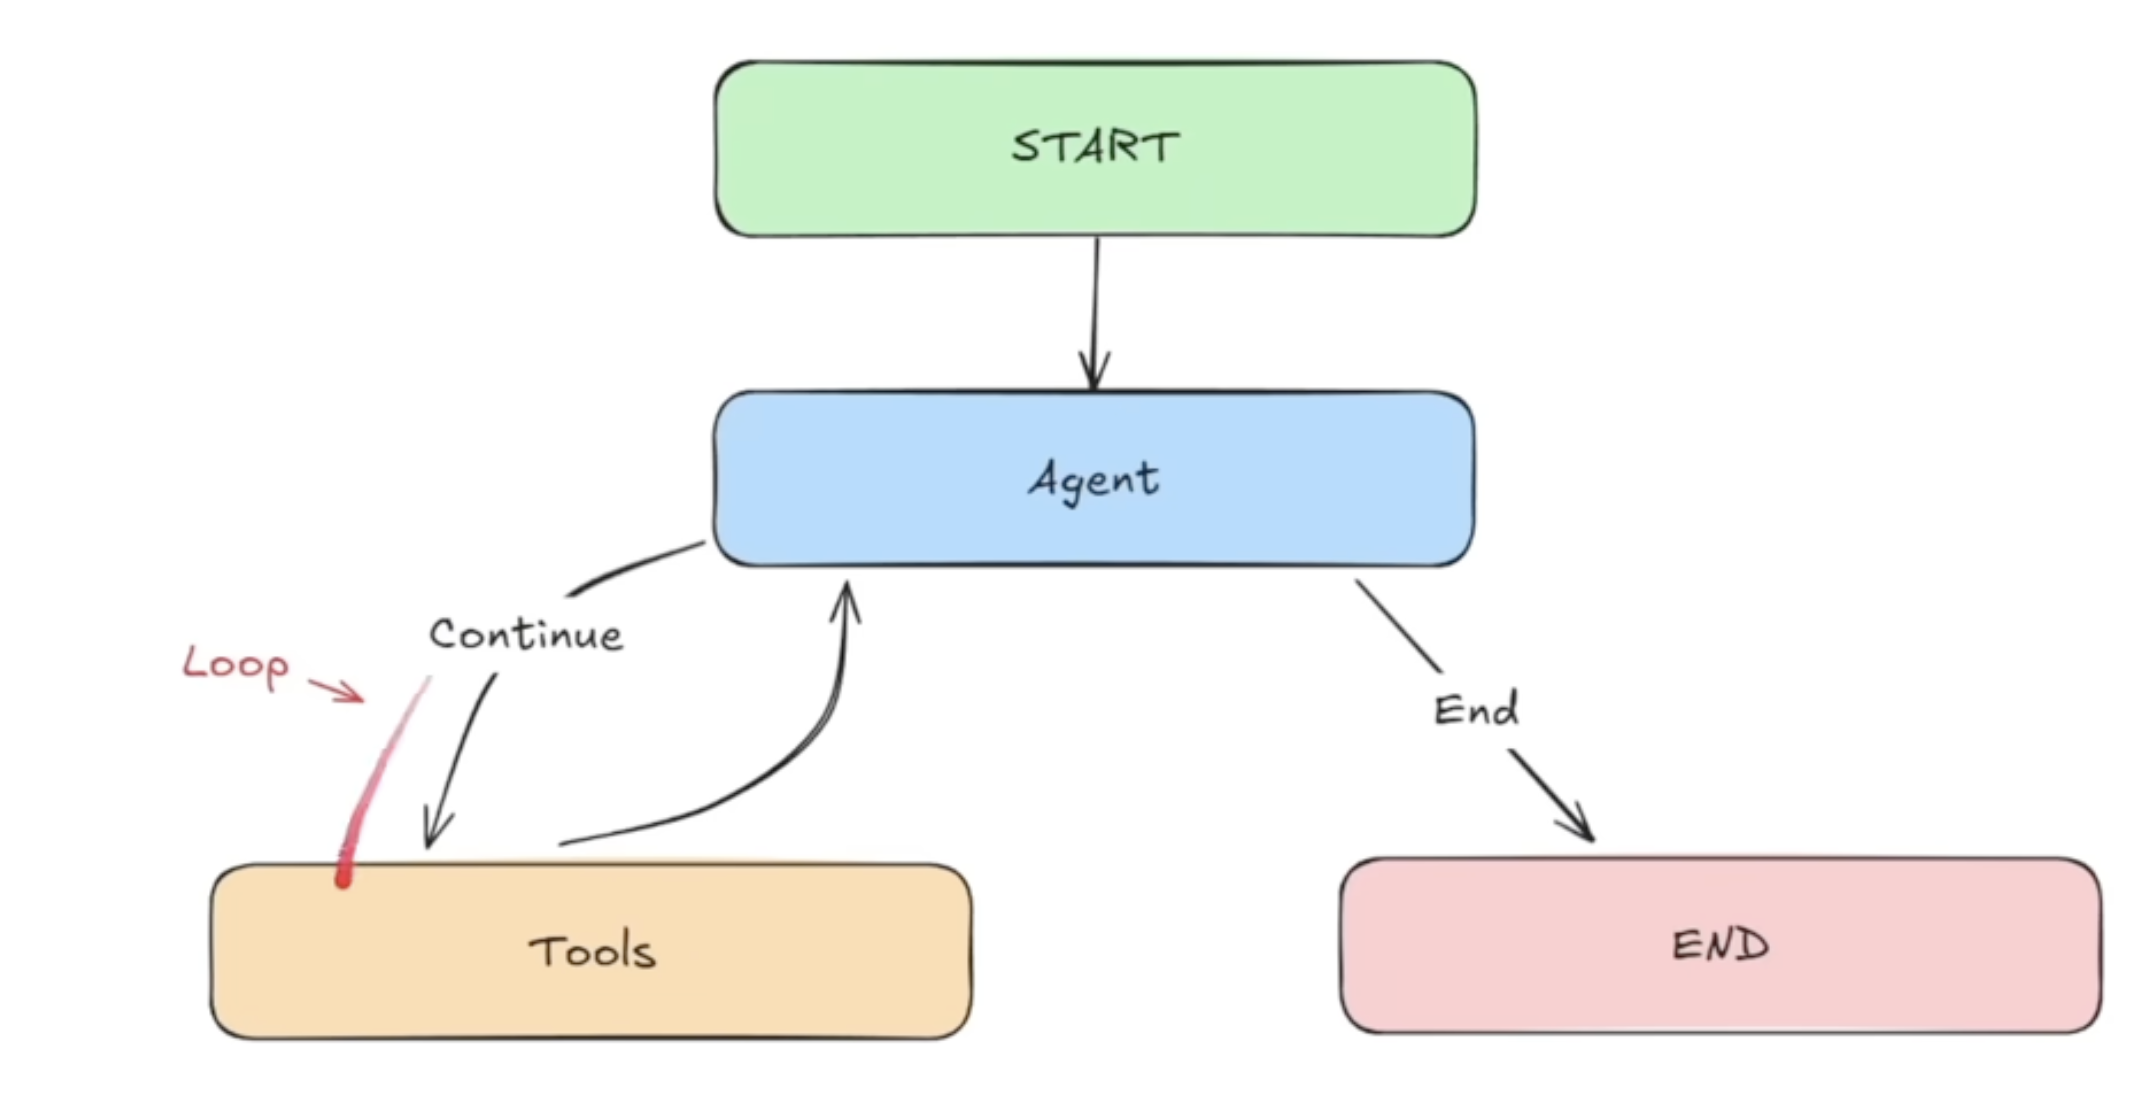

We attach tools to our agents and it is the agent job or llm in the background to decide which tools to select and use 

It is also its job to be able to decide when there is no more tool calling left to do. when that happens it goes to the end part

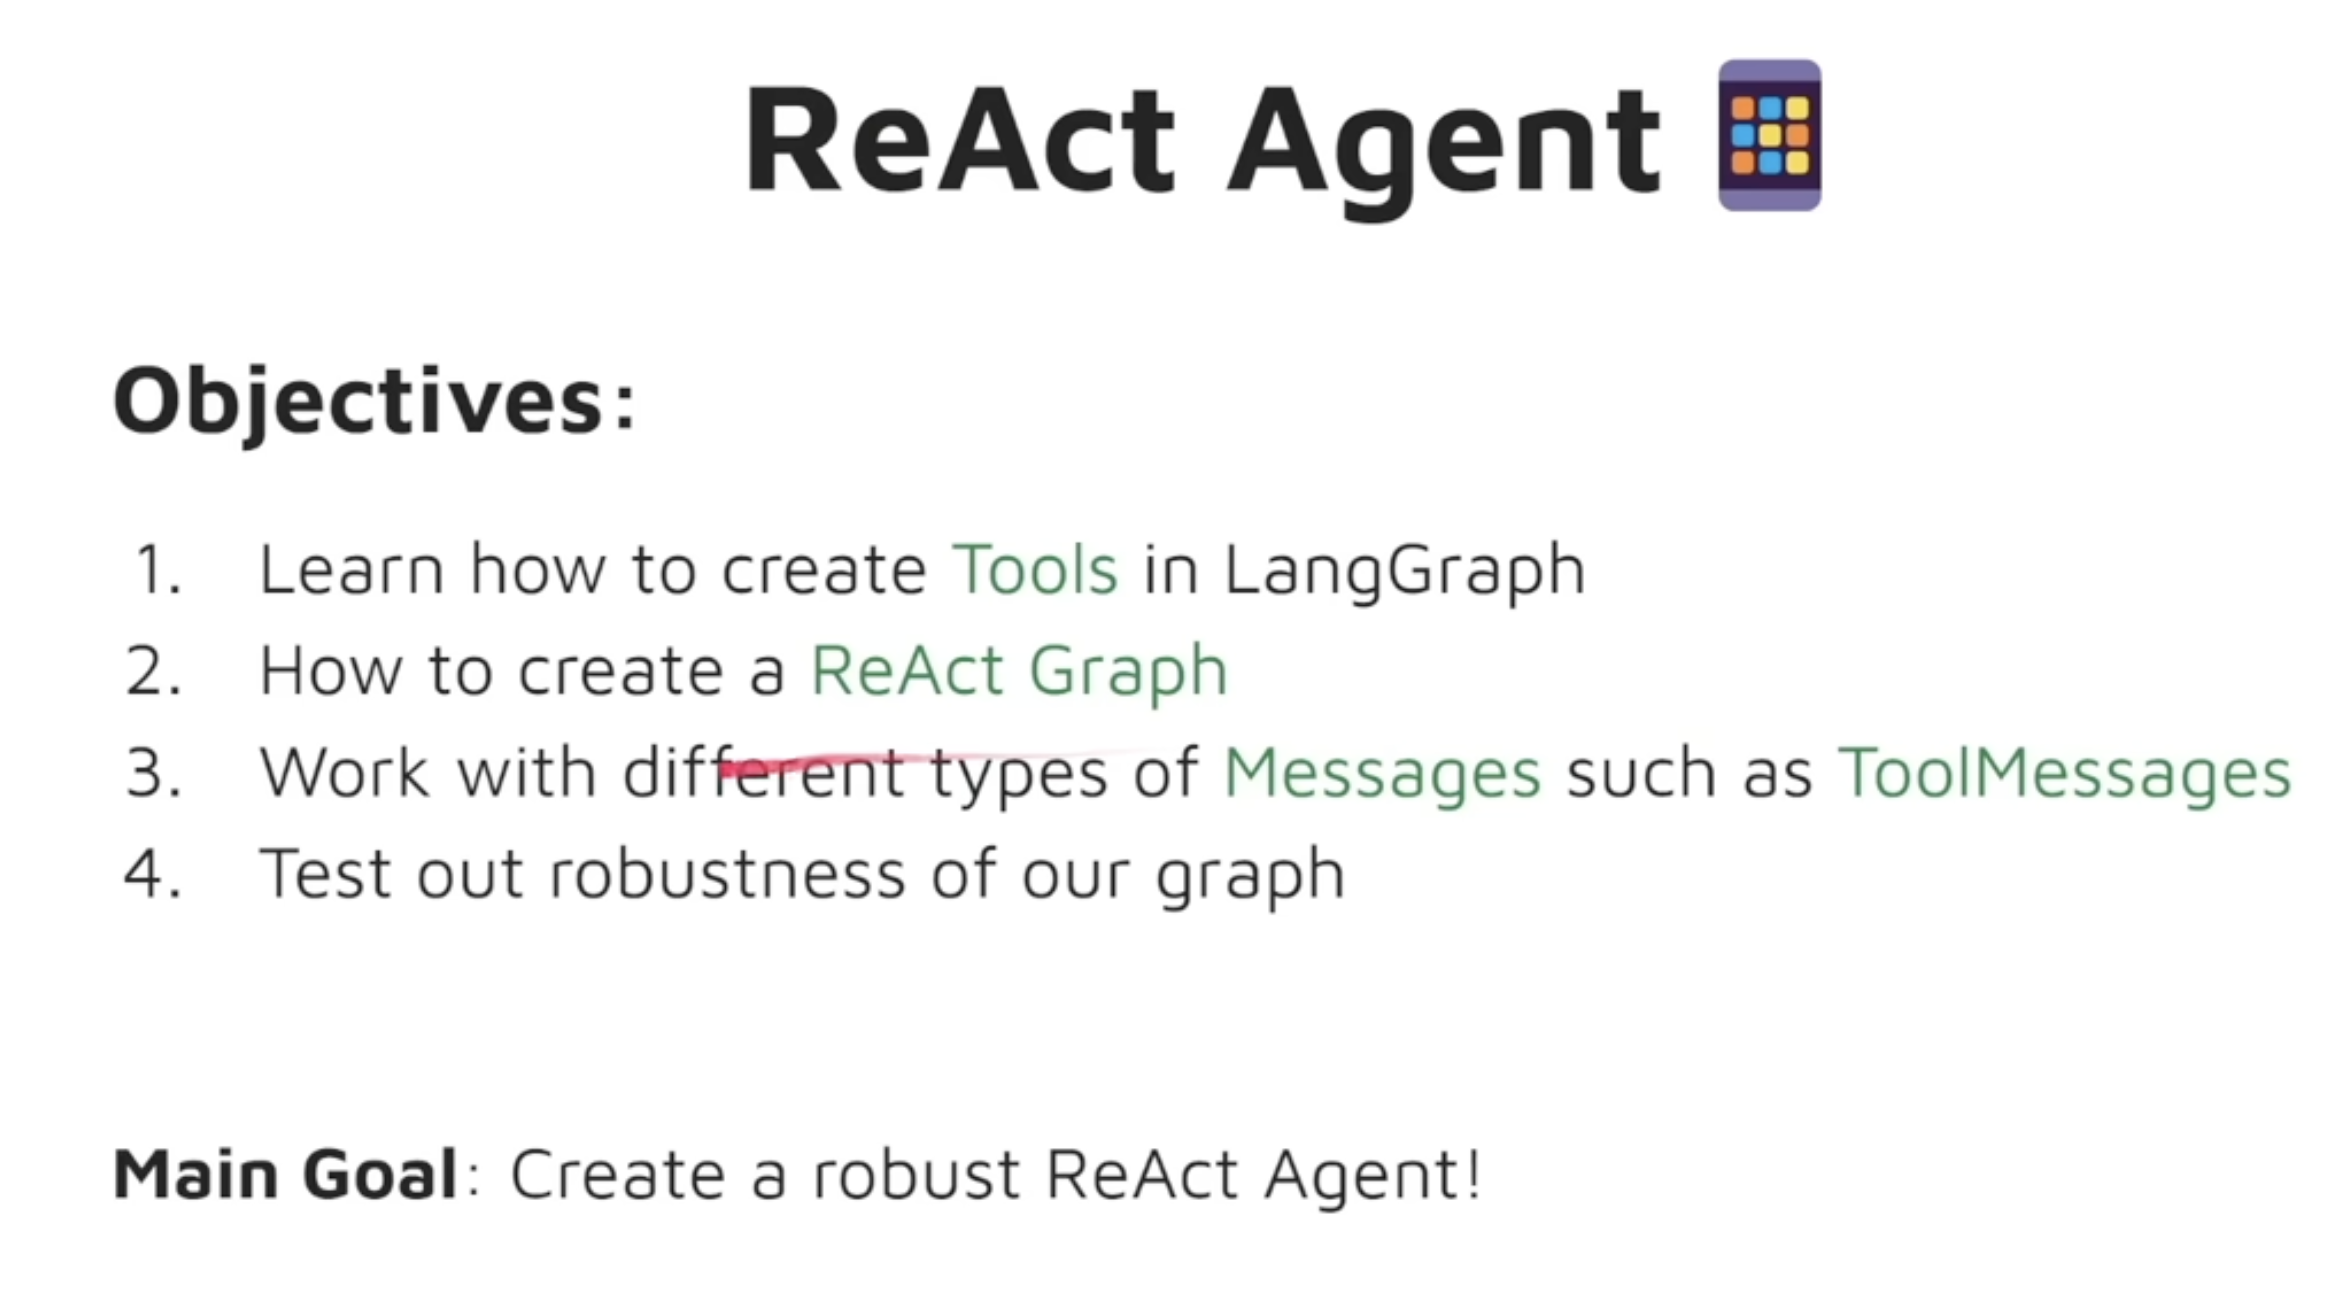

In [19]:
from typing import Sequence,TypedDict,Dict,List,Annotated
from dotenv import load_dotenv
from langgraph.graph import StateGraph,END,START
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import ToolMessage ## Type of message where the data is passed back to the LLM after the tool of LLM is being called.The info which is passed is like the content and tool_call_id
from langchain_core.messages import SystemMessage ## Type of message for providing instructions to the LLM ## ex- you are an expert recruiter
from langchain_core.messages import BaseMessage ## the foundational class for all message types in langgraph
from langchain_core.tools import tool
from langgraph.graph.message import add_messages ## add_messages is a reducer function that allows everything to append in the state
from langgraph.prebuilt import ToolNode

In [20]:
load_dotenv()

True

In [21]:
## BaseMessage is parent class and all other messages are its children class and child class inherits properties of base class

## Reducer function

In [22]:
# A reducer function is a Rule that controls how updates from nodes are combined with the existing state
# tells us how to merge new data into the current state

# without a reducer, updates would have replaced the existing value entirely! 

In [23]:
## Without a reducer 

state={'messages':['Hi!']}
update={'messages':['Nice to meet you!']}
new_state={'messages':['Nice to meet you!']}

## With a reducer

state={'messages':['Hi!']}
update={'messages':['Nice to meet you!']}
new_state={'messages':["Hi!","Nice to meet you!"]}

In [24]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

## Decorator

In [25]:
## Decorator tells python that this function is quite special

@tool
def add(a:int,b:int):
    ## if i remove this docstring then the agent won't work it will give error because agent doesn't know the utility of function
    """ This is an addition function that adds 2 numbers together"""

    return a+b


In [26]:
tools=[add]

In [27]:
## How to tell my model that these are the tools that you can use ?
## we use inbuilt function called bind_tools(list of tools)

In [28]:
model=ChatGoogleGenerativeAI(model='gemini-2.5-flash').bind_tools(tools)

In [29]:
def model_call(state:AgentState)->AgentState:
    system_prompt=SystemMessage(content=['You are my AI assistant, plz ans my query to the best of your ability.'])
    response=model.invoke([system_prompt]+ state['messages'])
    return {'messages':[response]}
    

def should_continue(state:AgentState):
    messages=state['messages']
    last_message=messages[-1] ## we will see the last message and we will check if there is any more tools needed to re ran.
    if not last_message.tool_calls:
        return 'end'
    else:
        return 'continue'

graph=StateGraph(AgentState)
graph.add_node("our_agent",model_call)

In [30]:
tool_node=ToolNode(tools=tools)
graph.add_node("tools",tool_node)

In [31]:
graph.set_entry_point('our_agent')

graph.add_conditional_edges(
    'our_agent',
    should_continue,
    {
        'continue':'tools',
        'end':END
    }
)

graph.add_edge('tools','our_agent')

app=graph.compile()

In [32]:
def print_stream(stream):
    for s in stream:
        message=s['messages'][-1]
        if isinstance(message,tuple):
            print(message)
        else:
            message.pretty_print()
inputs={'messages':[("user","Add 40 + 12")]}
print_stream(app.stream(inputs,stream_mode='values'))

================================ Human Message =================================

Add 40 + 12
================================== Ai Message ==================================
Tool Calls:
  add (5e26f381-3d82-47d2-b6b7-3c80d60c887f)
 Call ID: 5e26f381-3d82-47d2-b6b7-3c80d60c887f
  Args:
    a: 40
    b: 12
================================= Tool Message =================================
Name: add

52
================================== Ai Message ==================================

40 + 12 = 52.


In [33]:
inputs={'messages':[("user","Add 40 + 12. Add 3+4")]}
print_stream(app.stream(inputs,stream_mode='values'))

================================ Human Message =================================

Add 40 + 12. Add 3+4
================================== Ai Message ==================================
Tool Calls:
  add (16bb23b4-513a-45dc-8343-f5277184a42f)
 Call ID: 16bb23b4-513a-45dc-8343-f5277184a42f
  Args:
    a: 40
    b: 12
  add (e16c0ced-2261-4837-80e4-c977dfe9ec26)
 Call ID: e16c0ced-2261-4837-80e4-c977dfe9ec26
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 40 and 12 is 52. The sum of 3 and 4 is 7.


## Important: 

Tool calls is an indication that LLM didn't use its inbuilt information which it was trained on to come up with the answer..LLM doesn't know maths, it just guesses the next most probable output

LLM actually decides what should be passed as arguments to each tool.. for ex add 3 and 4

so in the add function it will pass arguments 3 and 4 in the fn 

## Multiple Tools

In [38]:
from typing import Sequence,TypedDict,Dict,List,Annotated
from dotenv import load_dotenv
from langgraph.graph import StateGraph,END,START
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import ToolMessage ## Type of message where the data is passed back to the LLM after the tool of LLM is being called.The info which is passed is like the content and tool_call_id
from langchain_core.messages import SystemMessage ## Type of message for providing instructions to the LLM ## ex- you are an expert recruiter
from langchain_core.messages import BaseMessage ## the foundational class for all message types in langgraph
from langchain_core.tools import tool
from langgraph.graph.message import add_messages ## add_messages is a reducer function that allows everything to append in the state
from langgraph.prebuilt import ToolNode
load_dotenv()
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

## Decorator tells python that this function is quite special
@tool
def add(a:int,b:int):
    ## if i remove this docstring then the agent won't work it will give error because agent doesn't know the utility of function
    """ This is an addition function that adds 2 numbers together"""

    return a+b

@tool
def subtract(a:int,b:int):
    ''' this is a subtraction function that subtracts 2 numbers together'''
    return a-b

@tool
def multiply(a:int,b:int):
    ''' this is a multiply function that multiplies 2 numbers together'''
    return a*b

tools=[add,subtract,multiply]

model=ChatGoogleGenerativeAI(model='gemini-2.5-flash').bind_tools(tools)


def model_call(state:AgentState)->AgentState:
    system_prompt=SystemMessage(content=['You are my AI assistant, plz ans my query to the best of your ability.'])
    response=model.invoke([system_prompt]+ state['messages'])
    return {'messages':[response]}
    

def should_continue(state:AgentState):
    messages=state['messages']
    last_message=messages[-1] ## we will see the last message and we will check if there is any more tools needed to re ran.
    if not last_message.tool_calls:
        return 'end'
    else:
        return 'continue'

graph=StateGraph(AgentState)
graph.add_node("our_agent",model_call)
graph.set_entry_point('our_agent')

tool_node=ToolNode(tools=tools)
graph.add_node('tool_node',tool_node)
graph.add_edge('tool_node','our_agent')
graph.add_conditional_edges(
    'our_agent',
    should_continue,
    {
        'end':END,
        'continue':'tool_node'
    }
)

app=graph.compile()

In [40]:
def print_stream(stream):
    for s in stream:
        message=s['messages'][-1]
        if isinstance(message,tuple):
            print(message)
        else:
            message.pretty_print()
inputs={'messages':[("user","Add 40 + 12")]}
print_stream(app.stream(inputs,stream_mode='values'))

================================ Human Message =================================

Add 40 + 12
================================== Ai Message ==================================
Tool Calls:
  add (2511ba25-1c5e-46d0-b10a-bdd372d5f393)
 Call ID: 2511ba25-1c5e-46d0-b10a-bdd372d5f393
  Args:
    b: 12
    a: 40
================================= Tool Message =================================
Name: add

52
================================== Ai Message ==================================

The sum of 40 and 12 is 52.


In [43]:
def print_stream(stream):
    for s in stream:
        message=s['messages'][-1]
        if isinstance(message,tuple):
            print(message)
        else:
            message.pretty_print()
inputs={'messages':[("user","Multiply 40 * 12.Then subtract it from 39")]}
print_stream(app.stream(inputs,stream_mode='values'))

================================ Human Message =================================

Multiply 40 * 12.Then subtract it from 39
================================== Ai Message ==================================
Tool Calls:
  multiply (a69957a5-fcd9-490f-97bc-f4d9a1087b20)
 Call ID: a69957a5-fcd9-490f-97bc-f4d9a1087b20
  Args:
    a: 40
    b: 12
================================= Tool Message =================================
Name: multiply

480
================================== Ai Message ==================================
Tool Calls:
  subtract (3fe115f4-2e27-4e30-b017-6a59a7c8990a)
 Call ID: 3fe115f4-2e27-4e30-b017-6a59a7c8990a
  Args:
    a: 39
    b: 480
================================= Tool Message =================================
Name: subtract

-441
================================== Ai Message ==================================

The answer is -441.


In [ ]:
## the LLM decides what should be passed as arguments 

## Agent IV: Drafter (Mini Project)

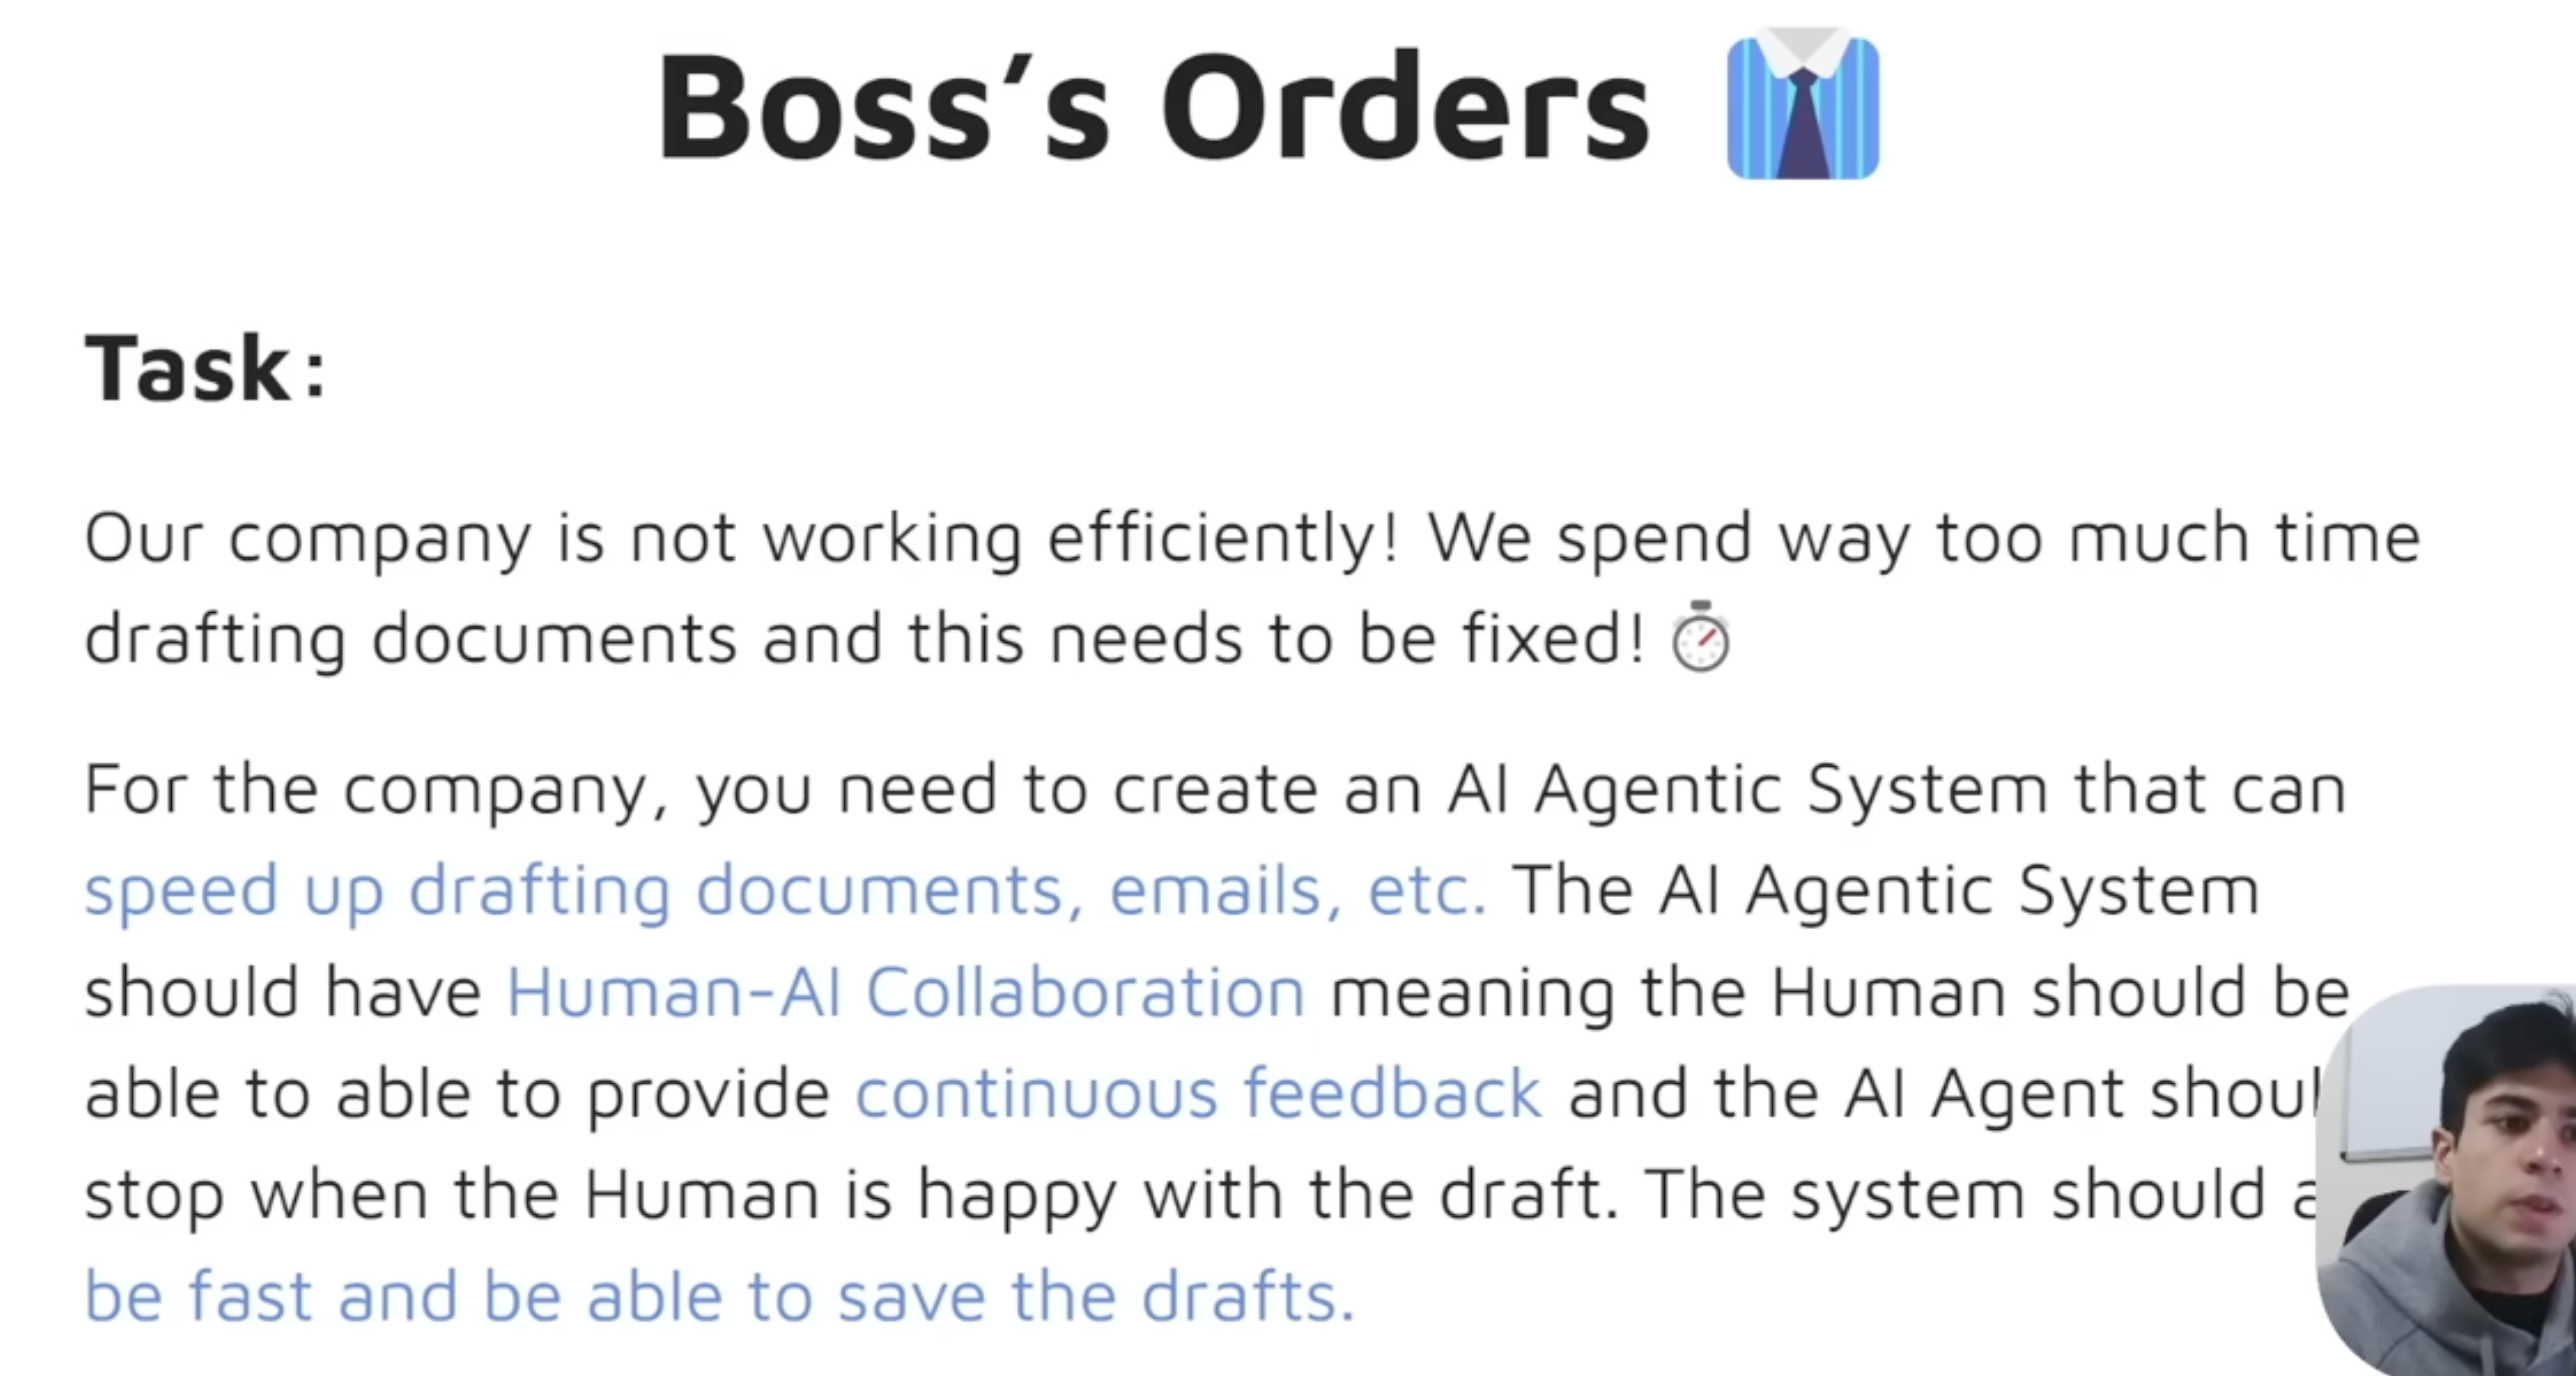

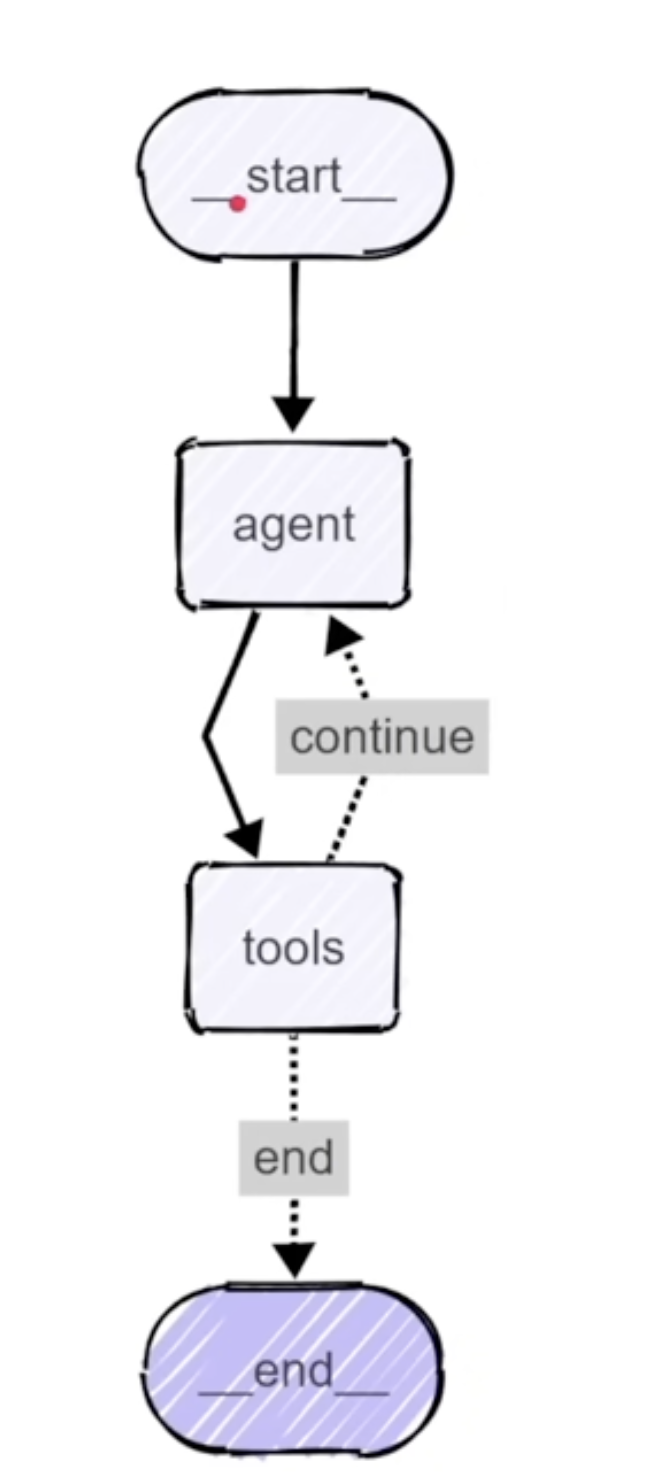

In [ ]:
# one of the tool is save tool. it will save the drafts. But once we saved it, the process should end 
# in ReAct agent, the tools always go back to the ai agent not to the endpoint.we dont want that anymore

In [40]:
from typing import Annotated,TypedDict,Sequence
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,ToolMessage,SystemMessage,HumanMessage,AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
load_dotenv()

## this is a global variable used to store document content (don't need to pass it as a state and it will be directly saved by tools as well)

doc_content=""


class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

@tool
def update(content:str)->str: ##LLM will provide the content we will just update it 
    '''updates the document with the provided content'''
    ## To interact with global variable in python
    global doc_content 
    doc_content=content
    return f"Document has been updated successfully, the current content is:\n {doc_content}"

@tool
def save(filename:str)->str: ##LLM will give a filename we will just save it 
    '''Save the current document to a text file and finish the process
    
    Args:
         filename:Name of the text file
    '''
    global doc_content
    if not filename.endswith('.txt'):
        filename=f"{filename}.txt"

    try:
        with open(filename,'w') as file:
            file.write(doc_content)
        print(f"\n the doc has been saved to: {filename}")
        return f"The document has been saved successfully to '{filename}."
    
    except Exception as e:
        return f"Error saving the document: {str(e)}"
    
    
 
tools=[update,save]
model=ChatGoogleGenerativeAI(model='gemini-2.5-flash').bind_tools(tools)



In [41]:
def our_agent(state:AgentState)->AgentState:
    system_prompt=SystemMessage(content=f"""
You are a Drafter,a helpful writing assistant. You are going to help the user update and modify documents.
                                
-If the user wants to update or modify content,then use 'update' tool with the complete updated content.
-If the user wants to save and finish, you need to use 'save' tool.                              
-Make sure to always show the current document state after modifications                             
the current document is:{doc_content}""")
    if not state['messages']: ## if empty
        user_input="I'm ready to help you update a document. What would you like to create? "
        user_message=HumanMessage(content=user_input)

    else: ## already passed a doc
        user_input=input("\n What would you like to do with the document?")
        print(f"\n User: {user_input}")
        user_message=HumanMessage(content=user_input)

    all_messages=[system_prompt]+list(state['messages'])+[user_message]
    response=model.invoke(all_messages)
    print(f" AI: {response.content}")
    if hasattr(response,"tool_calls") and response.tool_calls:
        print(f" Using Tools {[tc['name'] for tc in response.tool_calls]}")
        return {"messages": list(state["messages"]) + [user_message, response]}

def should_continue(state:AgentState):
    '''determine if we should continue or end the conversation'''
    messages=state['messages']
    if not messages:
        return "continue"
    
    ## this looks for the most recent tool message
    for message in reversed(messages):
        # checks if this is a ToolMessage resulting from save

        if (isinstance(message,ToolMessage) and "saved" in message.content.lower() and "document" in message.content.lower()):
            return "end"
        
    return "continue"

def print_messages(messages):
    '''function I made to print the messages in a more readable format'''
    if not messages:
        return
    
    ## latest 3 messages
    for message in messages[-3:]:
        if isinstance(message,ToolMessage):
            print(f"Tool Result: {message.content}")

graph=StateGraph(AgentState)

graph.add_node('agent',our_agent)
graph.add_node('tools',ToolNode(tools))
graph.add_edge(START,'agent')
graph.add_edge('agent','tools')

graph.add_conditional_edges(
    'tools',
    should_continue,
    {
        'end':END,
        'continue':'agent'
    }
)

app=graph.compile()

def run_doc_agent():
    print("\n ---DRAFTER---")

    state={"messages":[]}

    for step in app.stream(state,stream_mode='values'):
        if 'messages' in step:
            print_messages(step['messages'])
    print("\n ---DRAFTER FINISHED---")


## Agent V

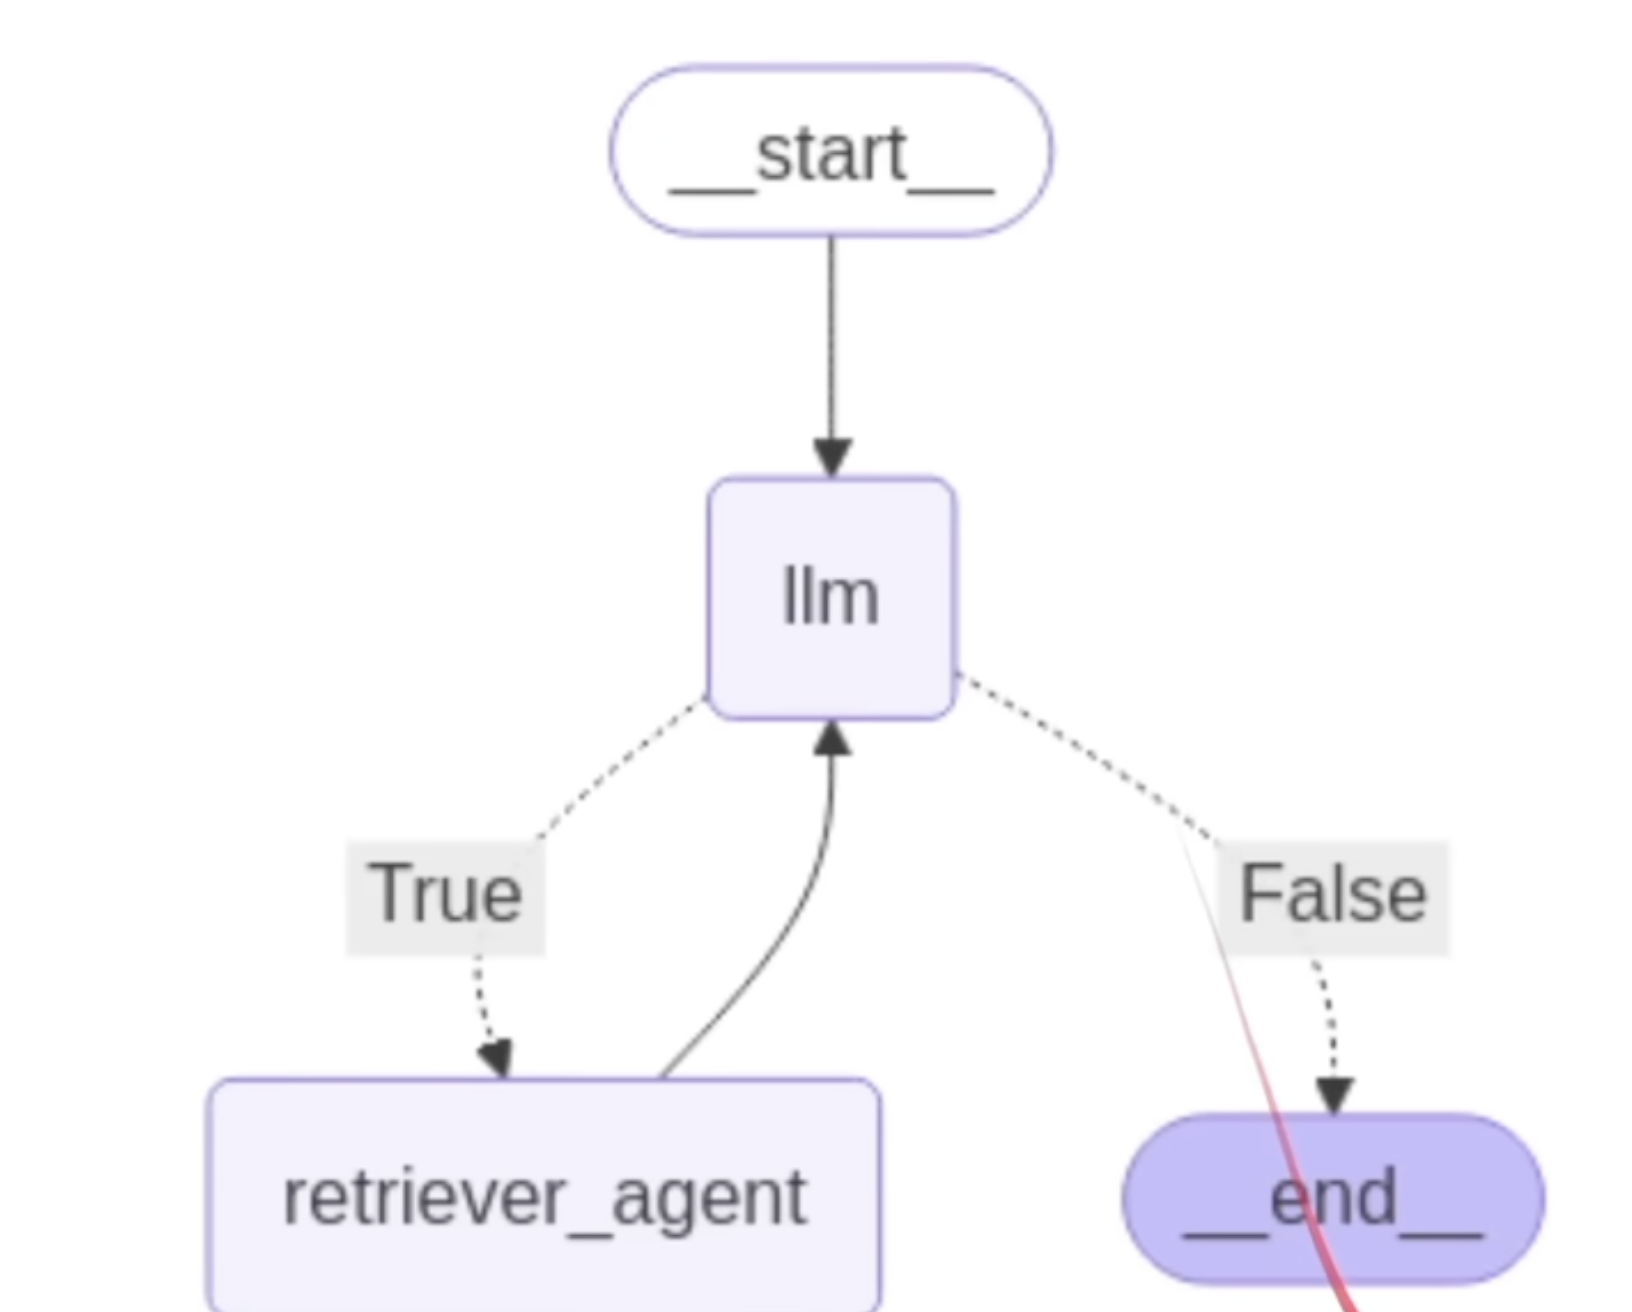